In [2]:
import numpy as np #array operations
from scipy.stats import norm #normal distribution functions
from scipy.optimize import brentq #root finding for implied volatility

In [3]:
def d1(S,K,T,r,sigma):
    return (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
def d2(S,K,T,r,sigma):
    return d1(S,K,T,r,sigma) - sigma * np.sqrt(T)
    

In [5]:
#Test cell testing defined equations
S=182
K=185
T= 90/365 # 90 days to maturity (T measured in years)
r=.053 # risk free rate
sigma= .25 #volatility
print(f"d1= {d1(S,K,T,r,sigma):.4f}")
print(f"d2= {d2(S,K,T,r,sigma):.4f}")

d1= 0.0356
d2= -0.0885


d1 represents the number of standard deviations a stock is from the strike, adjusting for time and "drift"
d2 risk neutral probability input for the stock option expiring "in the money."
With our values, it shows there is a slightly less than 50% chance the stock will finish above 185$ at this period in time.

In [6]:
print(f"N(d1) = {norm.cdf(0.0356):.4f}")
print(f"N(d2) = {norm.cdf(-0.0885):.4f}")

N(d1) = 0.5142
N(d2) = 0.4647


N(d2) = probability option expires in the money
N(d1)= delta-adjusted probability, delta is how much the option price moves for every dollar change in the asset price
"drift" is the expected direction one would expect a stock to go, in this example, we are assuming it will grow at the risk free rate, and the noise from the volatility may alter that short term.
N(d1)= delta, the amount of shares you need to short to hedge one option contract

Call price = (shares needed to hedge × stock price)
           − (probability of finishing ITM × discounted strike)
           
or more simply, 

Call price = what you gain from owning the stock hedge
           − what you pay out at expiry if exercised


In [7]:
from scipy.stats import norm

print(f"N(d1) = {norm.cdf(d1(S,K,T,r,sigma)):.4f}  ← your delta (hedge ratio)")
print(f"N(d2) = {norm.cdf(d2(S,K,T,r,sigma)):.4f}  ← probability of finishing ITM")
print()
print(f"Interpretation:")
print(f"  {norm.cdf(d2(S,K,T,r,sigma))*100:.1f}% chance Apple finishes above ${K}")
print(f"  Need to own {norm.cdf(d1(S,K,T,r,sigma)):.2f} shares to hedge 1 option contract")

N(d1) = 0.5142  ← your delta (hedge ratio)
N(d2) = 0.4647  ← probability of finishing ITM

Interpretation:
  46.5% chance Apple finishes above $185
  Need to own 0.51 shares to hedge 1 option contract


Call and Put Prices
Black Scholes formula for european options
call: right to by stock at strike K
put: right to sell stock at strike K

In [8]:
def call_price(S,K,T,r,sigma):
    return S * norm.cdf(d1(S,K,T,r,sigma)) - K * np.exp(-r*T) * norm.cdf(d2(S,K,T,r,sigma))
def put_price(S,K,T,r,sigma):
    return K * np.exp(-r*T) * norm.cdf(-d2(S,K,T,r,sigma)) - S * norm.cdf(-d1(S,K,T,r,sigma))

C  =  S · N(d1)          −        K · e^(−rT) · N(d2)

S * N(d1)=  hedge ratio
multiplying the value of the stock by the hedge proportion, this indicates the value of stock needed to hedge the stock option
"Cost of shares needed to back the option"

K* e^(-rT)* N(d2)
K* e^(-rT) is the strike price discounted back to todays value, as the strike price initially input was at maturity, which is multiplied by the probability that the option is in the money
"The expected cost of paying the strike price at maturity"

Price of call option is the difference betweeen these two terms

P  =  K · e^(−rT) · N(−d2)   −   S · N(−d1)
      ↑                            ↑
      Term 1                       Term 2

put option is opposite basically, where d1 and d2 are negative as you want to know probability that stock finishes below the strike, as that is what you look for in a put option

term 1 is expected value of receiving strike price at maturity

term 2 is the value of the stock that is delivered

In [11]:
call = round(call_price(S, K, T, r, sigma),2)

put  = round(put_price(S, K, T, r, sigma),2)

print(f"Call price : ${call:.2f}")
print(f"Put price  : ${put:.2f}")

Call price : $8.73
Put price  : $9.32


The Greeks
measures sensitivity the option price is to the inputs
- Delta : sensitivity to stock price
- Gamma : sensitivity of Delta to stock price  
- Theta : sensitivity to time
- Vega  : sensitivity to volatility
- Rho   : sensitivity to interest rate

In [12]:
#defining Delta 
def delta(S,K,T,r,sigma,option_type='call'):
    if option_type == 'call':
        return norm.cdf(d1(S,K,T,r,sigma))
    elif option_type == 'put':
        return norm.cdf(d1(S,K,T,r,sigma)) - 1
    else:
        raise ValueError("option_type must be 'call' or 'put'")

N(d1) is the hedge ratio also known as Delta, which represents the amount the option price moves based on $1 move in the stock. If it is a put option, we calculate this with N(d1)-1 as option will gain value as stock decreases.

In [13]:
# defining Gamma
def gamma(S,K,T,r,sigma):
    return norm.pdf(d1(S,K,T,r,sigma)) / (S * sigma * np.sqrt(T))

Mathmatically the second derivative, or the rate of change of delta, which is the rate of change in the options price with respect to the stock price. This value helps us understand at what rate does your hedging need to change, when the stock price moves.
The higher the value for gamma, the more frequently the rebalancing of your hedging needs to happen.

In [15]:
#Defining theta
def theta(S,K,T,r,sigma,option_type='call'):
    if option_type == 'call':
        return (-S * norm.pdf(d1(S,K,T,r,sigma)) * sigma / (2 * np.sqrt(T)) 
                - r * K * np.exp(-r*T) * norm.cdf(d2(S,K,T,r,sigma)))
    elif option_type == 'put':
        return (-S * norm.pdf(d1(S,K,T,r,sigma)) * sigma / (2 * np.sqrt(T)) 
                + r * K * np.exp(-r*T) * norm.cdf(-d2(S,K,T,r,sigma)))
    else:
        raise ValueError("option_type must be 'call' or 'put'")

Theta helps us understand the amount of money the options looses per **day** nearing maturity.

In [16]:
# defining Vega
def vega(S,K,T,r,sigma):
    return S * norm.pdf(d1(S,K,T,r,sigma)) * np.sqrt(T) / 100

Vega helps us understand the change in option price for every 1% change in the volatility of the stock. Vega stays positive for both options and puts due to the fact that options are more valuable the more the price of the stock fluctuates.

In [17]:
#defining Rho
def rho(S,K,T,r,sigma,option_type='call'):
    if option_type == 'call':
        return K * T * np.exp(-r*T) * norm.cdf(d2(S,K,T,r,sigma)) / 100
    elif option_type == 'put':
        return -K * T * np.exp(-r*T) * norm.cdf(-d2(S,K,T,r,sigma)) / 100
    else:
        raise ValueError("option_type must be 'call' or 'put'")

Rho helps us understand how the option price will change for every 1% change in the interest rate.

Now for our earlier example, we will calculate each of these.

In [19]:
call_delta = delta(S, K, T, r, sigma, "call")
put_delta  = delta(S, K, T, r, sigma, "put")
gam        = gamma(S, K, T, r, sigma)
call_theta = theta(S, K, T, r, sigma, "call")
call_vega  = vega(S, K, T, r, sigma)
call_rho   = rho(S, K, T, r, sigma, "call")


print()
print(f"Delta (call) : {call_delta:.4f}")
print(f"  → option moves ${call_delta:.2f} per $1 move in stock")
print(f"  → need to short {call_delta:.2f} shares to hedge 1 contract")
print()
print(f"Delta (put)  : {put_delta:.4f}")
print(f"  → option moves ${put_delta:.2f} per $1 move in stock")
print()
print(f"Gamma        : {gam:.6f}")
print(f"  → delta changes {gam:.4f} per $1 move in stock")
print()
print(f"Theta        : {call_theta:.4f} per day")
print(f"  → option loses ${abs(call_theta):.4f} per day")
print(f"  → over 30 days: ${abs(call_theta)*30:.2f} time decay")
print()
print(f"Vega         : {call_vega:.4f} per 1% vol move")
print(f"  → option gains ${call_vega:.4f} per 1% rise in vol")
print()
print(f"Rho          : {call_rho:.4f} per 1% rate move")
print(f"  → option gains ${call_rho:.4f} per 1% rise in rates")


Delta (call) : 0.5142
  → option moves $0.51 per $1 move in stock
  → need to short 0.51 shares to hedge 1 contract

Delta (put)  : -0.4858
  → option moves $-0.49 per $1 move in stock

Gamma        : 0.017646
  → delta changes 0.0176 per $1 move in stock

Theta        : -22.7635 per day
  → option loses $22.7635 per day
  → over 30 days: $682.91 time decay

Vega         : 0.3603 per 1% vol move
  → option gains $0.3603 per 1% rise in vol

Rho          : 0.2092 per 1% rate move
  → option gains $0.2092 per 1% rise in rates


***Implied Volatility***

Given the market prices for an option, what is the implied volatility?

In [22]:
def implied_volatility(market_price, S, K, T, r, option_type="call"):
    if option_type == "call":
        intrinsic = max(S - K * np.exp(-r * T), 0)
        price_fn  = call_price
    else:
        intrinsic = max(K * np.exp(-r * T) - S, 0)
        price_fn  = put_price
    
    # Can't solve if price is below intrinsic value
    if market_price <= intrinsic:
        return np.nan
    
    # Objective function — we want this to equal zero
    objective = lambda sigma: price_fn(S, K, T, r, sigma) - market_price
    
    try:
        iv = brentq(objective, 1e-6, 10.0, xtol=1e-6, maxiter=500)
        return round(iv, 6)
    except ValueError:
        return np.nan

In [23]:
# Simulate observing a market price and solving for IV
observed_price = call_price(S, K, T, r, 0.30)   # market pricing at 30% vol
your_forecast  = 0.25                             # you think vol is only 25%

iv = implied_volatility(observed_price, S, K, T, r, "call")

print(f"===== Implied Volatility Solver =====")
print()
print(f"Observed market price  : ${observed_price:.4f}")
print(f"Solved implied vol     : {iv*100:.2f}%")
print(f"Your forecast vol      : {your_forecast*100:.2f}%")
print(f"Difference             : {(your_forecast - iv)*100:+.2f}%")
print()
if your_forecast < iv:
    print(f"  ► Market OVERPRICING  → SELL the call")
    print(f"    Market implies {iv*100:.1f}% vol, you forecast {your_forecast*100:.1f}%")
elif your_forecast > iv:
    print(f"  ► Market UNDERPRICING → BUY the call")
    print(f"    Market implies {iv*100:.1f}% vol, you forecast {your_forecast*100:.1f}%")
else:
    print(f"  ► Fairly priced — no edge")

===== Implied Volatility Solver =====

Observed market price  : $10.5276
Solved implied vol     : 30.00%
Your forecast vol      : 25.00%
Difference             : -5.00%

  ► Market OVERPRICING  → SELL the call
    Market implies 30.0% vol, you forecast 25.0%


Computing Note: Volatility is found within the cumulative distributions of d1 and d2, so we cannot pull it out algebraically. using brentq closes in on the volatility values by narrowing its range until the market price matches the value for the calculated call or option price.

## Developing the Full Options Chain

In [24]:
def options_chain(S, T, r, sigma, n_strikes=11, width=0.20):
    low     = S * (1 - width)
    high    = S * (1 + width)
    strikes = np.linspace(low, high, n_strikes)
    
    chain = []
    for K in strikes:
        if abs(S - K) / S < 0.02:
            moneyness = "ATM"
        elif S > K:
            moneyness = "ITM"
        else:
            moneyness = "OTM"
        
        chain.append({
            "strike"    : round(K, 2),
            "call"      : round(call_price(S, K, T, r, sigma), 4),
            "put"       : round(put_price(S, K, T, r, sigma), 4),
            "delta"     : round(delta(S, K, T, r, sigma), 4),
            "gamma"     : round(gamma(S, K, T, r, sigma), 6),
            "vega"      : round(vega(S, K, T, r, sigma), 4),
            "moneyness" : moneyness,
        })
    
    return pd.DataFrame(chain)

In [26]:
import pandas as pd

# Market chain — what the market prices at 30% vol
mkt_chain  = options_chain(S, T, r, sigma=0.30)

# Your chain — what you think fair value is at 25% vol
your_chain = options_chain(S, T, r, sigma=0.25)

# Add your prices and edge to the market chain
mkt_chain["your_call"] = your_chain["call"]
mkt_chain["edge"]      = (mkt_chain["your_call"] - mkt_chain["call"]).round(4)
mkt_chain["signal"]    = mkt_chain["edge"].apply(
    lambda e: "BUY ▲" if e > 0.05 else ("SELL ▼" if e < -0.05 else "—")
)

print()
print(mkt_chain[["strike","moneyness","call","your_call","edge","signal","delta","vega"]].to_string(index=False))


 strike moneyness    call  your_call    edge signal  delta   vega
 145.60       ITM 38.8684    38.5104 -0.3580 SELL ▼ 0.9516 0.0909
 152.88       ITM 32.3304    31.6937 -0.6367 SELL ▼ 0.9087 0.1484
 160.16       ITM 26.2468    25.2654 -0.9814 SELL ▼ 0.8462 0.2142
 167.44       ITM 20.7590    19.4258 -1.3332 SELL ▼ 0.7648 0.2778
 174.72       ITM 15.9767    14.3582 -1.6185 SELL ▼ 0.6687 0.3278
 182.00       ATM 11.9588    10.1803 -1.7785 SELL ▼ 0.5644 0.3558
 189.28       OTM  8.7062     6.9174 -1.7888 SELL ▼ 0.4597 0.3587
 196.56       OTM  6.1677     4.5048 -1.6629 SELL ▼ 0.3615 0.3386
 203.84       OTM  4.2557     2.8141 -1.4416 SELL ▼ 0.2747 0.3014
 211.12       OTM  2.8631     1.6888 -1.1743 SELL ▼ 0.2021 0.2546
 218.40       OTM  1.8807     0.9755 -0.9052 SELL ▼ 0.1442 0.2052


In [28]:
import yfinance as yf
import pandas as pd
import numpy as np

# ── Change this to any ticker ──
TICKER = "AAPL"
PERIOD = "2y"
# ──────────────────────────────

stock = yf.Ticker(TICKER)
hist  = stock.history(period=PERIOD)

# Current stock price
S = hist["Close"].iloc[-1]

# Log returns
log_returns = np.log(hist["Close"] / hist["Close"].shift(1)).dropna()

# Annualised volatility over different windows
vol_30d  = log_returns[-30:].std()  * np.sqrt(252)
vol_60d  = log_returns[-60:].std()  * np.sqrt(252)
vol_252d = log_returns[-252:].std() * np.sqrt(252)

print(f"===== Market Data — {TICKER} =====")
print()
print(f"Current price    : ${S:.2f}")
print(f"Data range       : {hist.index[0].date()} → {hist.index[-1].date()}")
print(f"Trading days     : {len(hist)}")
print()
print(f"Historical Volatility")
print(f"  30-day  : {vol_30d*100:.1f}%  ← your forecast")
print(f"  60-day  : {vol_60d*100:.1f}%")
print(f"  252-day : {vol_252d*100:.1f}%  ← proxy for market")
print()

# Use these going forward
YOUR_FORECAST_VOL  = vol_30d
MARKET_IMPLIED_VOL = vol_252d
R                  = 0.053
K                  = round(S * 1.05, 0)
T                  = 90 / 365

print(f"Option Parameters")
print(f"  Strike (K)   : ${K:.0f}  (5% OTM)")
print(f"  Expiry (T)   : {T*365:.0f} days")
print(f"  Rate (r)     : {R*100:.1f}%")
print(f"  Your vol     : {YOUR_FORECAST_VOL*100:.1f}%")
print(f"  Market vol   : {MARKET_IMPLIED_VOL*100:.1f}%")

===== Market Data — AAPL =====

Current price    : $300.23
Data range       : 2024-05-16 → 2026-05-15
Trading days     : 501

Historical Volatility
  30-day  : 23.5%  ← your forecast
  60-day  : 22.5%
  252-day : 22.4%  ← proxy for market

Option Parameters
  Strike (K)   : $315  (5% OTM)
  Expiry (T)   : 90 days
  Rate (r)     : 5.3%
  Your vol     : 23.5%
  Market vol   : 22.4%


In [30]:
# Price using real market data
mkt_call  = call_price(S, K, T, R, MARKET_IMPLIED_VOL)
your_call = call_price(S, K, T, R, YOUR_FORECAST_VOL)
edge      = your_call - mkt_call

print(f"===== Live Pricing — {TICKER} =====")
print()
print(f"Market call price  : ${mkt_call:.4f}")
print(f"Your call price    : ${your_call:.4f}")
print(f"Edge per contract  : ${edge:+.4f}")
print()

# Greeks on real data
print(f"===== Greeks =====")
print()
print(f"Delta : {delta(S, K, T, R, MARKET_IMPLIED_VOL):.4f}")
print(f"Gamma : {gamma(S, K, T, R, MARKET_IMPLIED_VOL):.6f}")
print(f"Theta : {theta(S, K, T, R, MARKET_IMPLIED_VOL):.4f} per day")
print(f"Vega  : {vega(S, K, T, R, MARKET_IMPLIED_VOL):.4f} per 1% vol")
print()

# Full options chain on real data
chain = options_chain(S, T, R, MARKET_IMPLIED_VOL)
chain["your_call"] = options_chain(S, T, R, YOUR_FORECAST_VOL)["call"]
chain["edge"]      = (chain["your_call"] - chain["call"]).round(4)
chain["signal"]    = chain["edge"].apply(
    lambda e: "BUY ▲" if e > 0.05 else ("SELL ▼" if e < -0.05 else "—")
)

print(f"===== Options Chain =====")
print()
print(chain[["strike","moneyness","call","your_call","edge","signal","delta"]].to_string(index=False))

===== Live Pricing — AAPL =====

Market call price  : $8.8759
Your call price    : $9.5059
Edge per contract  : $+0.6300

===== Greeks =====

Delta : 0.3980
Gamma : 0.011553
Theta : -31.9896 per day
Vega  : 0.5752 per 1% vol

===== Options Chain =====

 strike moneyness    call  your_call   edge signal  delta
 240.18       ITM 63.3440    63.4113 0.0673  BUY ▲ 0.9853
 252.19       ITM 51.8873    52.0401 0.1528  BUY ▲ 0.9591
 264.20       ITM 40.9766    41.2580 0.2814  BUY ▲ 0.9070
 276.21       ITM 30.9949    31.4270 0.4321  BUY ▲ 0.8219
 288.22       ITM 22.3332    22.8980 0.5648  BUY ▲ 0.7054
 300.23       ATM 15.2699    15.9103 0.6404  BUY ▲ 0.5687
 312.24       OTM  9.8858    10.5261 0.6403  BUY ▲ 0.4288
 324.25       OTM  6.0568     6.6292 0.5724  BUY ▲ 0.3020
 336.26       OTM  3.5144     3.9776 0.4632  BUY ▲ 0.1989
 348.27       OTM  1.9346     2.2774 0.3428  BUY ▲ 0.1228
 360.28       OTM  1.0127     1.2470 0.2343  BUY ▲ 0.0713


In [33]:
import datetime

# ── Input today's date ──────────────────────────
TODAY = datetime.date.today()
TARGET_DAYS = 90
# ───────────────────────────────────────────────

# Find expiry closest to 90 days from today
target_date = TODAY + datetime.timedelta(days=TARGET_DAYS)

best_expiry = min(
    stock.options,
    key=lambda x: abs(
        datetime.datetime.strptime(x, '%Y-%m-%d').date() - target_date
    )
)

T_real = (datetime.datetime.strptime(best_expiry, '%Y-%m-%d').date() - TODAY).days / 365

print(f"Today          : {TODAY}")
print(f"Target date    : {target_date}  (90 days out)")
print(f"Closest expiry : {best_expiry}")
print(f"Days to expiry : {T_real*365:.0f}")
print()

# Pull the real chain
chain_real = stock.option_chain(best_expiry)
calls_real = chain_real.calls

# Filter strikes within 20% of current price
mask = (calls_real['strike'] >= S * 0.80) & (calls_real['strike'] <= S * 1.20)
calls_real = calls_real[mask].copy()

print(f"Real Market Options Chain — {TICKER}")
print(f"Expiry : {best_expiry}  ({T_real*365:.0f} days)")
print(f"Current price : ${S:.2f}")
print()
print(calls_real[['strike','bid','ask','lastPrice','volume','openInterest']].to_string(index=False))

Today          : 2026-05-19
Target date    : 2026-08-17  (90 days out)
Closest expiry : 2026-08-21
Days to expiry : 94

Real Market Options Chain — AAPL
Expiry : 2026-08-21  (94 days)
Current price : $300.23

 strike   bid   ask  lastPrice  volume  openInterest
  245.0 57.25 58.90      57.35     2.0           976
  250.0 52.85 54.50      52.99    25.0          2606
  255.0 48.25 49.85      48.71     5.0          1157
  260.0 44.15 45.65      44.35     6.0          5031
  265.0 39.85 41.30      40.26    27.0          2688
  270.0 35.85 37.05      35.55   183.0          4267
  275.0 31.80 32.75      31.95    10.0          4807
  280.0 28.05 29.00      28.46    35.0          6662
  285.0 24.45 25.40      24.38     7.0          5352
  290.0 21.15 22.05      21.04   156.0          7427
  295.0 18.10 18.95      18.60   183.0          5771
  300.0 15.45 16.00      15.51   454.0         17012
  305.0 13.10 13.55      13.25  1092.0          3596
  310.0 10.90 11.30      11.12   204.0         19

In [34]:
# Solve for implied vol on every strike
calls_real['mid_price'] = (calls_real['bid'] + calls_real['ask']) / 2

calls_real['implied_vol'] = calls_real.apply(
    lambda row: implied_volatility(
        row['mid_price'], S, row['strike'], T_real, R, 'call'
    ), axis=1
)

# Your forecast vol
calls_real['forecast_vol'] = YOUR_FORECAST_VOL
calls_real['vol_diff']     = (calls_real['forecast_vol'] - calls_real['implied_vol']).round(4)
calls_real['edge']         = calls_real.apply(
    lambda row: round(
        call_price(S, row['strike'], T_real, R, YOUR_FORECAST_VOL) -
        call_price(S, row['strike'], T_real, R, row['implied_vol']), 4
    ) if not np.isnan(row['implied_vol']) else np.nan,
    axis=1
)
calls_real['signal'] = calls_real['edge'].apply(
    lambda e: "BUY ▲" if e > 0.05 else ("SELL ▼" if e < -0.05 else "—") 
    if not np.isnan(e) else "—"
)

print(f"===== Real Implied Vol vs Your Forecast =====")
print(f"Your forecast vol : {YOUR_FORECAST_VOL*100:.1f}%")
print()
print(calls_real[['strike','mid_price','implied_vol','forecast_vol','vol_diff','edge','signal']].to_string(index=False))

===== Real Implied Vol vs Your Forecast =====
Your forecast vol : 23.5%

 strike  mid_price  implied_vol  forecast_vol  vol_diff   edge signal
  245.0     58.075          NaN      0.234936       NaN    NaN      —
  250.0     53.675     0.159935      0.234936    0.0750 0.6126  BUY ▲
  255.0     49.050     0.191642      0.234936    0.0433 0.6314  BUY ▲
  260.0     44.900     0.221790      0.234936    0.0131 0.2927  BUY ▲
  265.0     40.575     0.225222      0.234936    0.0097 0.2722  BUY ▲
  270.0     36.450     0.228426      0.234936    0.0065 0.2214  BUY ▲
  275.0     32.275     0.224402      0.234936    0.0105 0.4160  BUY ▲
  280.0     28.525     0.225966      0.234936    0.0090 0.4048  BUY ▲
  285.0     24.925     0.225292      0.234936    0.0096 0.4834  BUY ▲
  290.0     21.600     0.224946      0.234936    0.0100 0.5431  BUY ▲
  295.0     18.525     0.224171      0.234936    0.0108 0.6204  BUY ▲
  300.0     15.725     0.223288      0.234936    0.0116 0.6964  BUY ▲
  305.0     13.32

/var/folders/bz/zh3cc_4x5qvf1g730_vbcj180000gn/T/ipykernel_1065/2118488223.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['delta_val'] = plot_data['strike'].apply(


Chart saved → black_scholes_chart.png


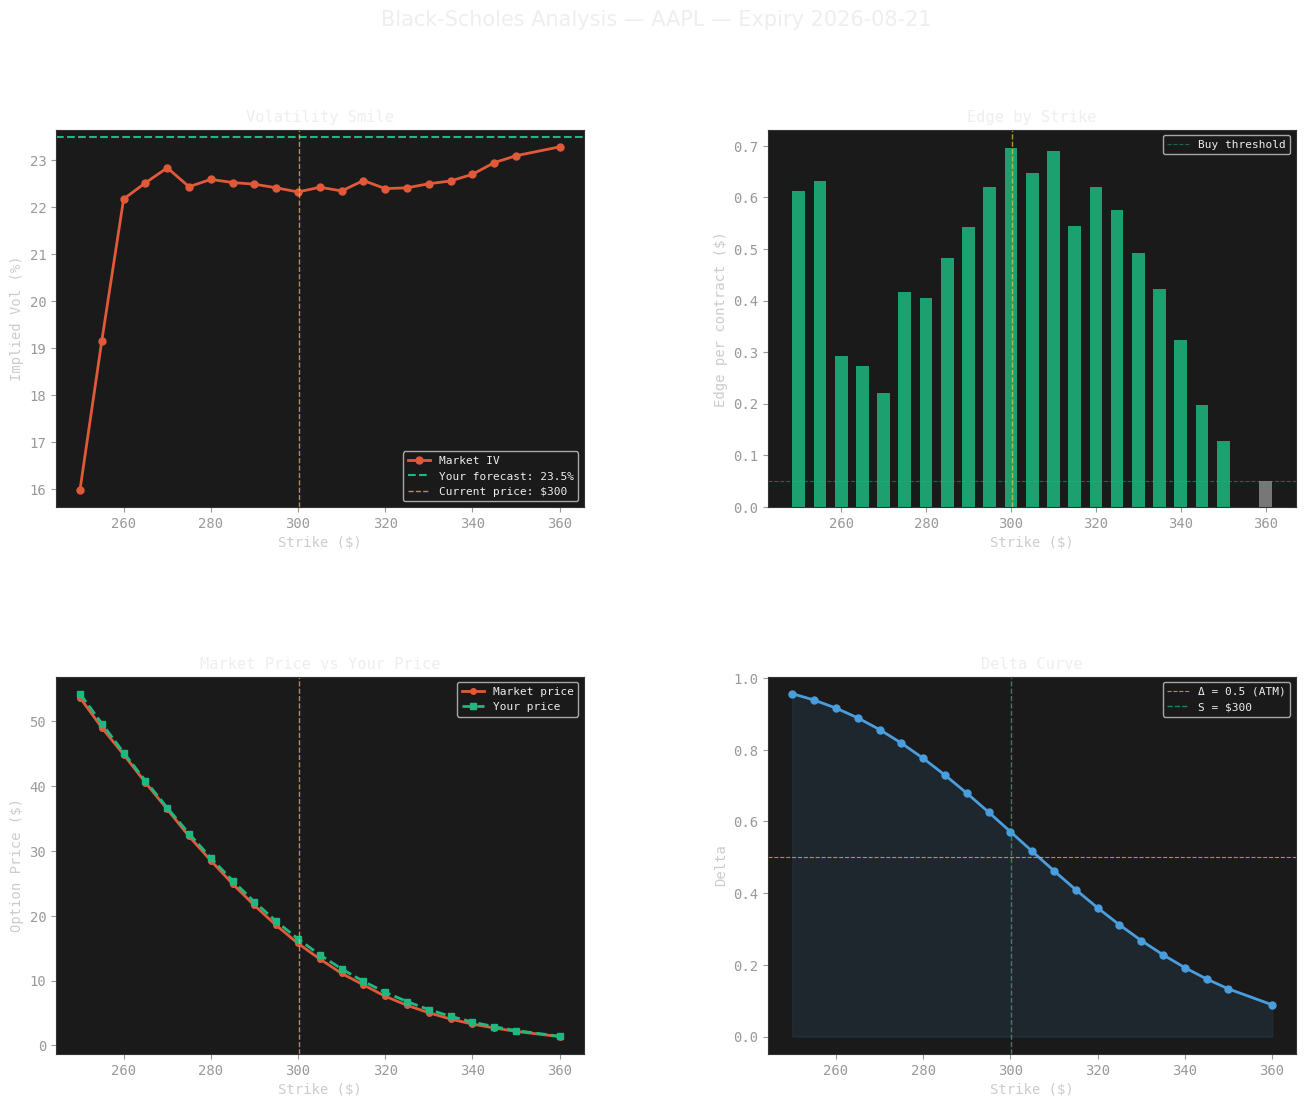

In [35]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Clean data — drop NaN rows
plot_data = calls_real.dropna(subset=['implied_vol', 'edge'])

fig = plt.figure(figsize=(16, 12))
fig.suptitle(f"Black-Scholes Analysis — {TICKER} — Expiry {best_expiry}",
             fontsize=15, y=0.98, color="#eeeeee")
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

TEAL   = "#1DB980"
CORAL  = "#E05A3A"
BLUE   = "#4A9EDD"
YELLOW = "#F5C542"

plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor"   : "#1a1a1a",
    "axes.edgecolor"   : "#333333",
    "axes.labelcolor"  : "#cccccc",
    "xtick.color"      : "#999999",
    "ytick.color"      : "#999999",
    "text.color"       : "#eeeeee",
    "grid.color"       : "#2a2a2a",
    "grid.linewidth"   : 0.5,
    "font.family"      : "monospace",
})

# ── Chart 1: Volatility smile
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(plot_data['strike'], plot_data['implied_vol'] * 100,
         color=CORAL, linewidth=2, marker='o', markersize=5, label='Market IV')
ax1.axhline(YOUR_FORECAST_VOL * 100, color=TEAL, linestyle='--',
            linewidth=1.5, label=f'Your forecast: {YOUR_FORECAST_VOL*100:.1f}%')
ax1.axvline(S, color=YELLOW, linestyle='--', linewidth=1,
            alpha=0.7, label=f'Current price: ${S:.0f}')
ax1.set_title('Volatility Smile', fontsize=11)
ax1.set_xlabel('Strike ($)')
ax1.set_ylabel('Implied Vol (%)')
ax1.legend(fontsize=8)

# ── Chart 2: Edge by strike
ax2 = fig.add_subplot(gs[0, 1])
colors = [TEAL if e > 0.05 else CORAL if e < -0.05 else "#888888"
          for e in plot_data['edge']]
ax2.bar(plot_data['strike'], plot_data['edge'], color=colors, alpha=0.85, width=3)
ax2.axhline(0, color='white', linewidth=0.5, alpha=0.3)
ax2.axhline(0.05, color=TEAL, linestyle='--', linewidth=0.8,
            alpha=0.5, label='Buy threshold')
ax2.axvline(S, color=YELLOW, linestyle='--', linewidth=1, alpha=0.7)
ax2.set_title('Edge by Strike', fontsize=11)
ax2.set_xlabel('Strike ($)')
ax2.set_ylabel('Edge per contract ($)')
ax2.legend(fontsize=8)

# ── Chart 3: Market price vs your price
ax3 = fig.add_subplot(gs[1, 0])
your_prices = plot_data['strike'].apply(
    lambda k: call_price(S, k, T_real, R, YOUR_FORECAST_VOL)
)
ax3.plot(plot_data['strike'], plot_data['mid_price'],
         color=CORAL, linewidth=2, marker='o', markersize=4, label='Market price')
ax3.plot(plot_data['strike'], your_prices,
         color=TEAL, linewidth=2, linestyle='--', marker='s',
         markersize=4, label='Your price')
ax3.axvline(S, color=YELLOW, linestyle='--', linewidth=1, alpha=0.7)
ax3.set_title('Market Price vs Your Price', fontsize=11)
ax3.set_xlabel('Strike ($)')
ax3.set_ylabel('Option Price ($)')
ax3.legend(fontsize=8)

# ── Chart 4: Delta curve
ax4 = fig.add_subplot(gs[1, 1])
plot_data['delta_val'] = plot_data['strike'].apply(
    lambda k: delta(S, k, T_real, R, YOUR_FORECAST_VOL)
)
ax4.plot(plot_data['strike'], plot_data['delta_val'],
         color=BLUE, linewidth=2, marker='o', markersize=5)
ax4.axhline(0.5, color=YELLOW, linestyle='--', linewidth=0.8,
            alpha=0.7, label='Δ = 0.5 (ATM)')
ax4.axvline(S, color=TEAL, linestyle='--', linewidth=1,
            alpha=0.7, label=f'S = ${S:.0f}')
ax4.fill_between(plot_data['strike'], plot_data['delta_val'],
                 alpha=0.1, color=BLUE)
ax4.set_title('Delta Curve', fontsize=11)
ax4.set_xlabel('Strike ($)')
ax4.set_ylabel('Delta')
ax4.legend(fontsize=8)

plt.savefig('black_scholes_chart.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
print("Chart saved → black_scholes_chart.png")
plt.show()